In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the CSV into a pandas DataFrame
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f"\nDataset '{fn}' loaded successfully!")
    display(df.head())
  except Exception as e:
    print(f"\nError loading dataset '{fn}': {e}")

Saving Indian_Kids_Screen_Time.csv to Indian_Kids_Screen_Time (1).csv
User uploaded file "Indian_Kids_Screen_Time (1).csv" with length 499126 bytes

Dataset 'Indian_Kids_Screen_Time (1).csv' loaded successfully!

Error loading dataset 'Indian_Kids_Screen_Time (1).csv': 'module' object is not callable


In [ ]:
df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [ ]:
 df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [ ]:
df.shape

(9712, 8)

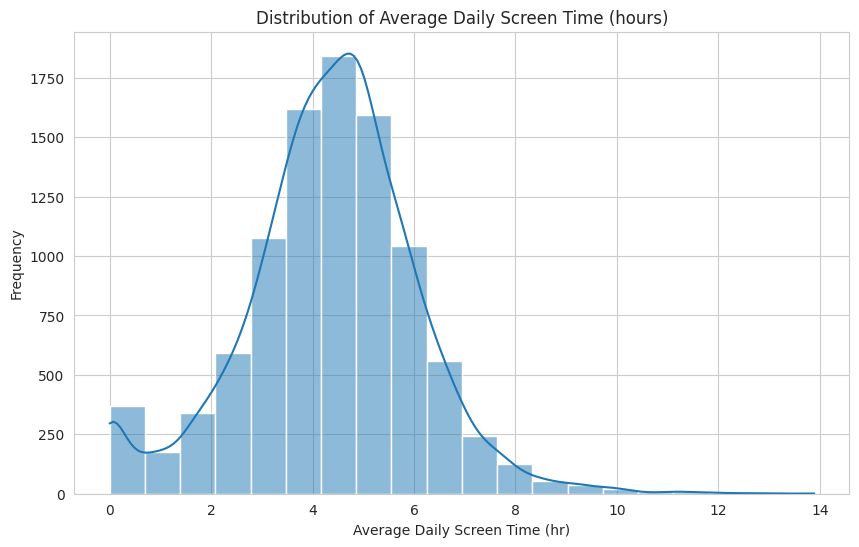

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# 2. Distribution of Avg_Daily_Screen_Time_hr
plt.figure(figsize=(10, 6))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], kde=True, bins=20)
plt.title('Distribution of Average Daily Screen Time (hours)')
plt.xlabel('Average Daily Screen Time (hr)')
plt.ylabel('Frequency')
plt.show()


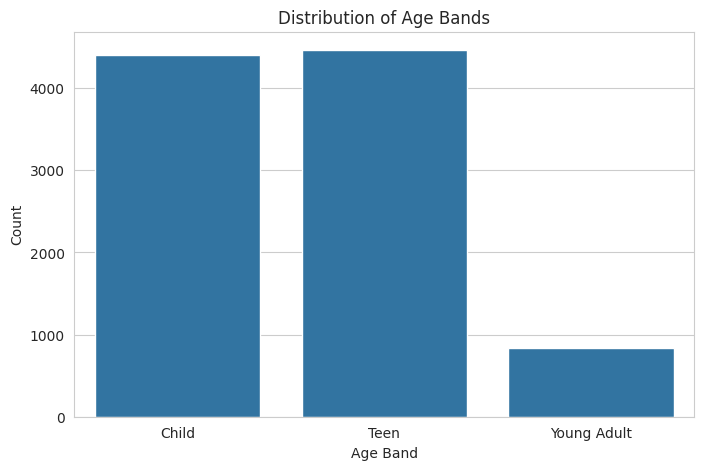

In [ ]:
# 3. Distribution of Age_Band
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age_Band', order=['Child', 'Teen', 'Young Adult'])
plt.title('Distribution of Age Bands')
plt.xlabel('Age Band')
plt.ylabel('Count')
plt.show()

**Note:** Make sure to run the data preprocessing cell (`89c4a063`) that creates the 'Age_Band' column before running this cell.

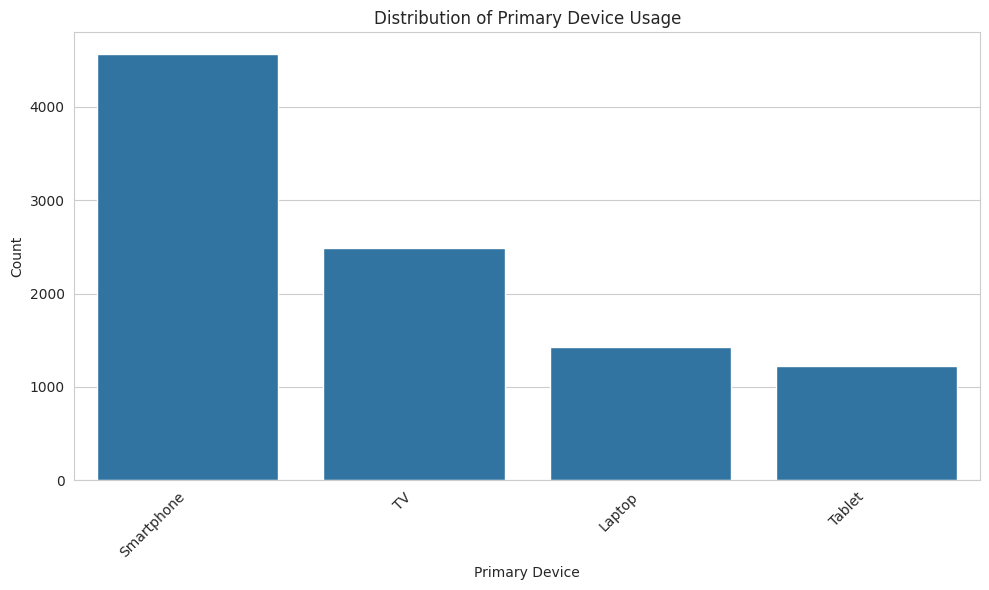

In [ ]:

# 4. Distribution of Primary_Device usage
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Primary_Device', order=df['Primary_Device'].value_counts().index)
plt.title('Distribution of Primary Device Usage')
plt.xlabel('Primary Device')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Address missing values in Health_Impacts
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# 2. Examine and unify categorical columns (assuming simple inconsistencies like casing)
# For more complex inconsistencies, more advanced techniques might be needed.
for col in ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip() # Convert to lowercase and remove leading/trailing whitespace
        # Add more specific cleaning if needed, e.g., replacing specific variations

# 3. Create 'Age_Band' column
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        return 'Young Adult'

df['Age_Band'] = df['Age'].apply(categorize_age)

# 4. Handle date/time fields (placeholder - no date/time columns in this schema)
# If there were date/time columns, we would convert them to datetime objects:
# df['date_column'] = pd.to_datetime(df['date_column'])

# 5. Create derived fields for device and activity shares (placeholder - schema doesn't support this directly)
# Based on Primary_Device, we can create dummy variables if needed for modeling:
# df = pd.get_dummies(df, columns=['Primary_Device'], prefix='Device', drop_first=True)
# Activity shares are not possible with the current schema.

# 6. Save the preprocessed DataFrame
df.to_csv('preprocessed_dataset.csv', index=False)

print("Data preprocessing and feature engineering complete. Preprocessed data saved to 'preprocessed_dataset.csv'.")
print(df.head())

Data preprocessing and feature engineering complete. Preprocessed data saved to 'preprocessed_dataset.csv'.
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    male                      3.99     smartphone   
1   11  female                      4.61         laptop   
2   18  female                      3.73             tv   
3   15  female                      1.21         laptop   
4   12  female                      5.89     smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural     Age_Band  
0  poor sleep, eye strain          urban         Teen  
1              p

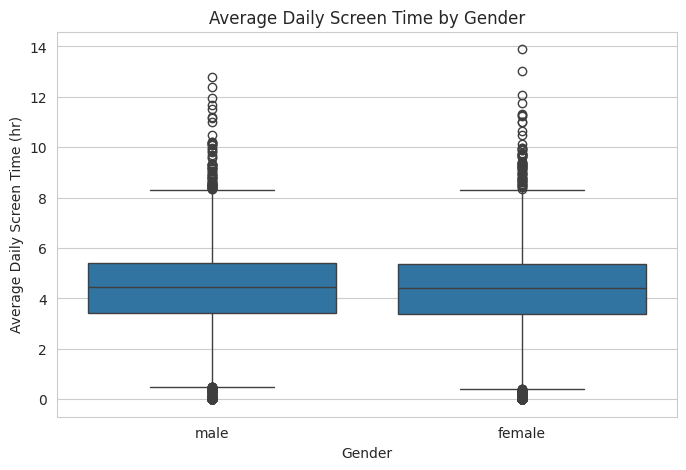

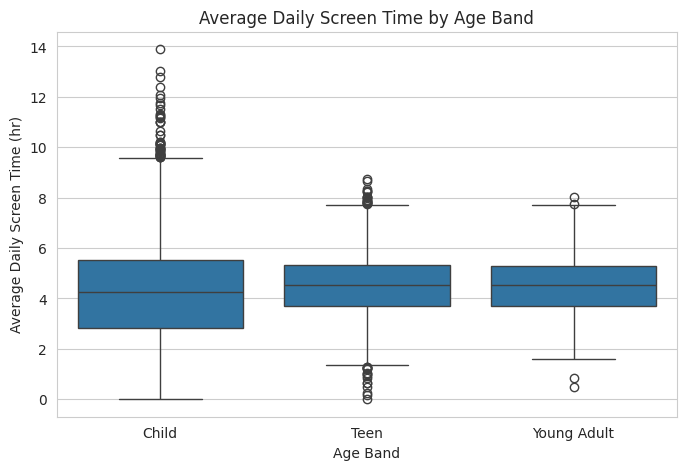

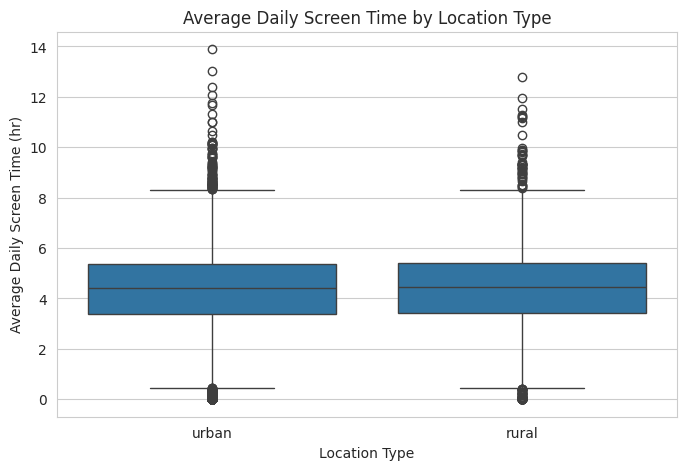

In [ ]:
# 5. Compare Avg_Daily_Screen_Time_hr across different Gender categories
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Avg_Daily_Screen_Time_hr')
plt.title('Average Daily Screen Time by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Daily Screen Time (hr)')
plt.show()

# 6. Compare Avg_Daily_Screen_Time_hr across different Age_Band categories
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Age_Band', y='Avg_Daily_Screen_Time_hr', order=['Child', 'Teen', 'Young Adult'])
plt.title('Average Daily Screen Time by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Average Daily Screen Time (hr)')
plt.show()

# 7. Compare Avg_Daily_Screen_Time_hr across different Urban_or_Rural categories
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr')
plt.title('Average Daily Screen Time by Location Type')
plt.xlabel('Location Type')
plt.ylabel('Average Daily Screen Time (hr)')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset contains 9712 rows and 8 columns, including numerical, categorical, and boolean data types.
*   The `Health_Impacts` column initially had a significant number of null values (3218), which were later filled with 'None' during preprocessing. Other columns had no missing values.
*   Preprocessing steps included handling missing values in `Health_Impacts`, unifying categorical values by converting them to lowercase, and creating an 'Age\_Band' column ('Child', 'Teen', 'Young Adult') based on the 'Age' column.
*   Visual analysis showed the distribution of average daily screen time, age bands, and primary device usage.
*   Box plots indicated how average daily screen time varies across gender, age bands, and location types.
*   Count plots illustrated the relationship between categorical variables (Gender, Age Band, Primary Device, Urban or Rural) and whether the recommended screen time limit was exceeded.

### Insights or Next Steps

*   Further analysis could quantify the differences in average daily screen time and the likelihood of exceeding limits across different demographic groups and device types.
*   Investigate specific health impacts mentioned in the data and their correlation with screen time or device usage patterns.


In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the CSV into a pandas DataFrame
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f"\nDataset '{fn}' loaded successfully!")
    display(df.head())
  except Exception as e:
    print(f"\nError loading dataset '{fn}': {e}")

# Data preprocessing steps (from cell d0e7bd09)
# 1. Address missing values in Health_Impacts
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# 2. Examine and unify categorical columns (assuming simple inconsistencies like casing)
# For more complex inconsistencies, more advanced techniques might be needed.
for col in ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip() # Convert to lowercase and remove leading/trailing whitespace
        # Add more specific cleaning if needed, e.g., replacing specific variations

# 3. Create 'Age_Band' column
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        return 'Young Adult'

df['Age_Band'] = df['Age'].apply(categorize_age)

# 4. Handle date/time fields (placeholder - no date/time columns in this schema)
# If there were date/time columns, we would convert them to datetime objects:
# df['date_column'] = pd.to_datetime(df['date_column'])

# 5. Create derived fields for device and activity shares (placeholder - schema doesn't support this directly)
# Based on Primary_Device, we can create dummy variables if needed for modeling:
# df = pd.get_dummies(df, columns=['Primary_Device'], prefix='Device', drop_first=True)
# Activity shares are not possible with the current schema.

print("\nData preprocessing and feature engineering complete.")

Saving Indian_Kids_Screen_Time.csv to Indian_Kids_Screen_Time (1).csv
User uploaded file "Indian_Kids_Screen_Time (1).csv" with length 499126 bytes

Dataset 'Indian_Kids_Screen_Time (1).csv' loaded successfully!


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban



Data preprocessing and feature engineering complete.


In [ ]:
df[df['Exceeded_Recommended_Limit'] == True].sort_values(by='Avg_Daily_Screen_Time_hr', ascending=True)


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
8152,8,female,2.01,smartphone,True,0.60,none,urban,Child
8532,9,male,2.01,tv,True,0.54,none,urban,Child
356,8,male,2.02,smartphone,True,0.57,none,urban,Child
3236,9,female,2.02,smartphone,True,0.40,none,urban,Child
696,8,female,2.03,tv,True,0.47,none,rural,Child
...,...,...,...,...,...,...,...,...,...
1321,10,female,12.09,tablet,True,0.45,poor sleep,urban,Child
1870,10,male,12.40,smartphone,True,0.52,none,urban,Child
1769,9,male,12.80,tv,True,0.56,"eye strain, anxiety",rural,Child
934,10,female,13.01,smartphone,True,0.57,"poor sleep, anxiety",urban,Child


In [ ]:
# Assuming 'df' is your DataFrame with 'Age', 'Gender', and 'Avg_Daily_Screen_Time_hr'
# and 'Exceeded_Recommended_Limit' columns, and 'Exceeded_Recommended_Limit' is boolean.

# Separate data into those within and exceeding the recommended limit
within_limit = df[df['Exceeded_Recommended_Limit'] == False]
above_limit = df[df['Exceeded_Recommended_Limit'] == True]

ages = sorted(df['Age'].unique())  # all unique ages in dataset
genders = df['Gender'].unique() # all unique genders in dataset
threshold_data = []

for age in ages:
    for gender in genders:
        # Find the maximum screen time for this age and gender group within the limit
        max_False = within_limit.loc[(within_limit['Age'] == age) & (within_limit['Gender'] == gender), 'Avg_Daily_Screen_Time_hr'].max()

        # Find the minimum screen time for this age and gender group above the limit
        min_True = above_limit.loc[(above_limit['Age'] == age) & (above_limit['Gender'] == gender), 'Avg_Daily_Screen_Time_hr'].min()

        # Determine the threshold: if both max_False and min_True exist, the threshold is the max_False
        # if the min_True is greater than max_False. Otherwise, the threshold is None.
        if pd.notna(max_False) and pd.notna(min_True):
             threshold = max_False if min_True > max_False else None
        else:
            threshold = None  # fallback if missing data for either group

        threshold_data.append({'Age': age, 'Gender': gender, 'Threshold_limit_hr': threshold})

threshold_df = pd.DataFrame(threshold_data).set_index(['Age', 'Gender'])

display(threshold_df)

Threshold_limit_hr
Age Gender                    
8   male                  1.99
    female                2.00
9   male                  1.99
    female                2.00
10  male                  1.98
    female                2.00
11  male                  2.99
    female                2.98
12  male                  3.00
    female                3.00
13  male                  2.99
    female                3.00
14  male                  2.90
    female                3.00
15  male                  3.00
    female                2.97
16  male                  2.98
    female                2.96
17  male                  2.98
    female                2.99
18  male                  2.98
    female                3.00

In [ ]:
# Find the minimum Avg_Daily_Screen_Time_hr where Exceeded_Recommended_Limit is True
threshold = df[df['Exceeded_Recommended_Limit'] == True]['Avg_Daily_Screen_Time_hr'].min()

print(f"The threshold for 'Avg_Daily_Screen_Time_hr' to exceed the recommended limit is: {threshold} hours")

The threshold for 'Avg_Daily_Screen_Time_hr' to exceed the recommended limit is: 2.01 hours


In [ ]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

import pandas as pd

df = pd.read_csv('/content/Indian_Kids_Screen_Time.csv')
exceeded_counts = ...
display(exceeded_counts)


,Age,Avg_Daily_Screen_Time_hr,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio
Age,1.000000,0.118328,0.159173,-0.488617
Avg_Daily_Screen_Time_hr,0.118328,1.000000,0.664950,-0.087552
Exceeded_Recommended_Limit,0.159173,0.664950,1.000000,-0.126643
Educational_to_Recreational_Ratio,-0.488617,-0.087552,-0.126643,1.000000


Ellipsis

In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the CSV into a pandas DataFrame
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f"\nDataset '{fn}' loaded successfully!")
    display(df.head())
  except Exception as e:
    print(f"\nError loading dataset '{fn}': {e}")

# Data preprocessing steps (from cell d0e7bd09)
# 1. Address missing values in Health_Impacts
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# 2. Examine and unify categorical columns (assuming simple inconsistencies like casing)
# For more complex inconsistencies, more advanced techniques might be needed.
for col in ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip() # Convert to lowercase and remove leading/trailing whitespace
        # Add more specific cleaning if needed, e.g., replacing specific variations

# 3. Create 'Age_Band' column
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        return 'Young Adult'

df['Age_Band'] = df['Age'].apply(categorize_age)

# 4. Handle date/time fields (placeholder - no date/time columns in this schema)
# If there were date/time columns, we would convert them to datetime objects:
# df['date_column'] = pd.to_datetime(df['date_column'])

# 5. Create derived fields for device and activity shares (placeholder - schema doesn't support this directly)
# Based on Primary_Device, we can create dummy variables if needed for modeling:
# df = pd.get_dummies(df, columns=['Primary_Device'], prefix='Device', drop_first=True)
# Activity shares are not possible with the current schema.

print("\nData preprocessing and feature engineering complete.")

average_metrics_by_gender = df.groupby('Gender')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_gender)

average_metrics_by_device = df.groupby('Primary_Device')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_device)

average_metrics_by_location = df.groupby('Urban_or_Rural')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_location)

average_metrics_by_age = df.groupby('Age_Band')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_age)

average_metrics_by_health_impacts = df.groupby('Health_Impacts')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_health_impacts)

Saving Indian_Kids_Screen_Time.csv to Indian_Kids_Screen_Time (1).csv
User uploaded file "Indian_Kids_Screen_Time (1).csv" with length 499126 bytes

Dataset 'Indian_Kids_Screen_Time (1).csv' loaded successfully!


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban



Data preprocessing and feature engineering complete.


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Gender,,
female,4.327021,0.426694
male,4.377754,0.427740


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Primary_Device,,
laptop,4.459086,0.399002
smartphone,4.388925,0.422077
tablet,4.226005,0.446005
tv,4.287752,0.443703


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Urban_or_Rural,,
rural,4.373702,0.427864
urban,4.344123,0.426960


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Age_Band,,
Child,4.161296,0.461457
Teen,4.513456,0.398970
Young Adult,4.503976,0.397833


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Health_Impacts,,
anxiety,4.903403,0.419974
"anxiety, obesity risk",4.648841,0.409855
eye strain,4.809301,0.420062
"eye strain, anxiety",5.081185,0.420444
"eye strain, anxiety, obesity risk",4.993429,0.425714
"eye strain, obesity risk",4.949811,0.431132
none,3.213254,0.441774
obesity risk,4.911151,0.420635
poor sleep,4.955445,0.421424


In [ ]:
age = int(input('Enter your child\'s age in years:'))
screen_time = float(input('Enter their screen time used in hours:'))
Gen = input('Enter the gender as either "Male" or "Female":')

if age in threshold_df.index.to_list():
    limit = threshold_df.loc[age, 'Threshold_limit_hr']

    # Only check if within the valid range
    if limit is not None:
        if screen_time > limit:
            print(f"You are exceeding the recommended limit of {limit} hours for a {age} years old !!!")
        else:
            print(f"You are within the safe recommended limit of {limit} hours for a {age} years old !!!")



Enter your child's age in years:18
Enter their screen time used in hours:2
Enter the gender as either "Male" or "Female":mae


  OCTOBER 30 DATA VISUALISATION WORKs

# Task
Build a recommendation system that takes user input for screen usage data (age, gender, screen time, etc.) and provides meaningful insights based on the specific age group and gender, using the preprocessed data and insights gained from the analysis.

In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the CSV into a pandas DataFrame
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f"\nDataset '{fn}' loaded successfully!")
    display(df.head())
  except Exception as e:
    print(f"\nError loading dataset '{fn}': {e}")

# Data preprocessing steps (from cell d0e7bd09)
# 1. Address missing values in Health_Impacts
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# 2. Examine and unify categorical columns (assuming simple inconsistencies like casing)
# For more complex inconsistencies, more advanced techniques might be needed.
for col in ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip() # Convert to lowercase and remove leading/trailing whitespace
        # Add more specific cleaning if needed, e.g., replacing specific variations

# 3. Create 'Age_Band' column
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        return 'Young Adult'

df['Age_Band'] = df['Age'].apply(categorize_age)

# 4. Handle date/time fields (placeholder - no date/time columns in this schema)
# If there were date/time columns, we would convert them to datetime objects:
# df['date_column'] = pd.to_datetime(df['date_column'])

# 5. Create derived fields for device and activity shares (placeholder - schema doesn't support this directly)
# Based on Primary_Device, we can create dummy variables if needed for modeling:
# df = pd.get_dummies(df, columns=['Primary_Device'], prefix='Device', drop_first=True)
# Activity shares are not possible with the current schema.

print("\nData preprocessing and feature engineering complete.")

average_metrics_by_gender = df.groupby('Gender')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_gender)

average_metrics_by_device = df.groupby('Primary_Device')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_device)

average_metrics_by_location = df.groupby('Urban_or_Rural')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_location)

average_metrics_by_age = df.groupby('Age_Band')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_age)

average_metrics_by_health_impacts = df.groupby('Health_Impacts')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
display(average_metrics_by_health_impacts)

Saving Indian_Kids_Screen_Time.csv to Indian_Kids_Screen_Time.csv
User uploaded file "Indian_Kids_Screen_Time.csv" with length 499126 bytes

Dataset 'Indian_Kids_Screen_Time.csv' loaded successfully!


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban



Data preprocessing and feature engineering complete.


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Gender,,
female,4.327021,0.426694
male,4.377754,0.427740


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Primary_Device,,
laptop,4.459086,0.399002
smartphone,4.388925,0.422077
tablet,4.226005,0.446005
tv,4.287752,0.443703


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Urban_or_Rural,,
rural,4.373702,0.427864
urban,4.344123,0.426960


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Age_Band,,
Child,4.161296,0.461457
Teen,4.513456,0.398970
Young Adult,4.503976,0.397833


,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
Health_Impacts,,
anxiety,4.903403,0.419974
"anxiety, obesity risk",4.648841,0.409855
eye strain,4.809301,0.420062
"eye strain, anxiety",5.081185,0.420444
"eye strain, anxiety, obesity risk",4.993429,0.425714
"eye strain, obesity risk",4.949811,0.431132
none,3.213254,0.441774
obesity risk,4.911151,0.420635
poor sleep,4.955445,0.421424


In [ ]:
# 1. Address missing values in Health_Impacts
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# 2. Examine and unify categorical columns (assuming simple inconsistencies like casing)
for col in ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip()

# 3. Create 'Age_Band' column
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        return 'Young Adult'

df['Age_Band'] = df['Age'].apply(categorize_age)

display(df.isnull().sum())
display(df.head())

,0
Age,0
Gender,0
Avg_Daily_Screen_Time_hr,0
Primary_Device,0
Exceeded_Recommended_Limit,0
Educational_to_Recreational_Ratio,0
Health_Impacts,0
Urban_or_Rural,0
Age_Band,0


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,male,3.99,smartphone,True,0.42,"poor sleep, eye strain",urban,Teen
1,11,female,4.61,laptop,True,0.30,poor sleep,urban,Child
2,18,female,3.73,tv,True,0.32,poor sleep,urban,Young Adult
3,15,female,1.21,laptop,False,0.39,none,urban,Teen
4,12,female,5.89,smartphone,True,0.49,"poor sleep, anxiety",urban,Child


In [ ]:
# Assuming 'df' is your DataFrame with 'Age', 'Gender', and 'Avg_Daily_Screen_Time_hr'
# and 'Exceeded_Recommended_Limit' columns, and 'Exceeded_Recommended_Limit' is boolean.

# Separate data into those within and exceeding the recommended limit
within_limit = df[df['Exceeded_Recommended_Limit'] == False]
above_limit = df[df['Exceeded_Recommended_Limit'] == True]

ages = sorted(df['Age'].unique())  # all unique ages in dataset
genders = df['Gender'].unique() # all unique genders in dataset
threshold_data = []

for age in ages:
    for gender in genders:
        # Find the maximum screen time for this age and gender group within the limit
        max_False = within_limit.loc[(within_limit['Age'] == age) & (within_limit['Gender'] == gender), 'Avg_Daily_Screen_Time_hr'].max()

        # Find the minimum screen time for this age and gender group above the limit
        min_True = above_limit.loc[(above_limit['Age'] == age) & (above_limit['Gender'] == gender), 'Avg_Daily_Screen_Time_hr'].min()

        # Determine the threshold: if both max_False and min_True exist, the threshold is the max_False
        # if the min_True is greater than max_False. Otherwise, the threshold is None.
        if pd.notna(max_False) and pd.notna(min_True):
             threshold = max_False if min_True > max_False else None
        else:
            threshold = None  # fallback if missing data for either group

        threshold_data.append({'Age': age, 'Gender': gender, 'Threshold_limit_hr': threshold})

threshold_df = pd.DataFrame(threshold_data).set_index(['Age', 'Gender'])

display(threshold_df)

Threshold_limit_hr
Age Gender                    
8   male                  1.99
    female                2.00
9   male                  1.99
    female                2.00
10  male                  1.98
    female                2.00
11  male                  2.99
    female                2.98
12  male                  3.00
    female                3.00
13  male                  2.99
    female                3.00
14  male                  2.90
    female                3.00
15  male                  3.00
    female                2.97
16  male                  2.98
    female                2.96
17  male                  2.98
    female                2.99
18  male                  2.98
    female                3.00

In [ ]:
def generate_screen_time_recommendation(age, gender, screen_time, primary_device, health_impacts, threshold_df, average_metrics_by_age, average_metrics_by_gender, average_metrics_by_device, average_metrics_by_health_impacts):
    """
    Generates a screen time recommendation based on user input and precalculated data.

    Args:
        age (int): The user's age.
        gender (str): The user's gender ('male' or 'female').
        screen_time (float): The user's average daily screen time in hours.
        primary_device (str): The user's primary device.
        health_impacts (str): The health impacts experienced by the user.
        threshold_df (pd.DataFrame): DataFrame containing screen time thresholds by age and gender.
        average_metrics_by_age (pd.DataFrame): DataFrame containing average metrics by age band.
        average_metrics_by_gender (pd.DataFrame): DataFrame containing average metrics by gender.
        average_metrics_by_device (pd.DataFrame): DataFrame containing average metrics by device.
        average_metrics_by_health_impacts (pd.DataFrame): DataFrame containing average metrics by health impacts.

    Returns:
        list: A list of strings, where each string is a line of the recommendation message.
    """
    recommendation_message = ""
    gender = gender.lower().strip()
    primary_device = primary_device.lower().strip()
    health_impacts = health_impacts.lower().strip()

    # Determine age band
    if age <= 12:
        age_band = 'Child'
    elif 13 <= age <= 17:
        age_band = 'Teen'
    else:
        age_band = 'Young Adult'


    # 1. Look up the recommended screen time limit based on age band and gender
    # Find the closest age in the threshold_df for the given age band
    if age_band == 'Child':
        # For children, use the threshold of the youngest age in the threshold_df (age 8)
        closest_age_in_threshold = 8
    elif age_band == 'Teen':
        # For teens, use the threshold of the youngest age in the teen range in the threshold_df (age 13)
        closest_age_in_threshold = 13
    else: # Young Adult
         # For young adults, use the threshold of the youngest age in the young adult range in the threshold_df (age 18)
        closest_age_in_threshold = 18

    try:
        limit = threshold_df.loc[(closest_age_in_threshold, gender), 'Threshold_limit_hr']
    except KeyError:
        recommendation_message+=(f"Warning: Could not find a specific threshold for age band {age_band} and gender '{gender}'.\n")
        limit = None # Set limit to None if not found

    # 2. Compare user's screen time with the threshold and generate message
    if limit is not None:
        if screen_time > limit:
            recommendation_message+=(f"Your screen time of {screen_time:.2f} hours per day exceeds the recommended limit of {limit:.2f} hours for a {age_band} ({age} years old) {gender}.\n")
        else:
            recommendation_message+=(f"Your screen time of {screen_time:.2f} hours per day is within the recommended limit of {limit:.2f} hours for a {age_band} ({age} years old) {gender}.\n")

    # 3. Incorporate average metrics for context
    try:
        avg_screen_time_age = average_metrics_by_age.loc[age_band, 'Avg_Daily_Screen_Time_hr']
        avg_ratio_age = average_metrics_by_age.loc[age_band, 'Educational_to_Recreational_Ratio']
        recommendation_message+=(f"The average daily screen time for {age_band}s is {avg_screen_time_age:.2f} hours, with an average educational to recreational ratio of {avg_ratio_age:.2f}.\n")
    except KeyError:
         recommendation_message+=(f"Could not find average metrics for {age_band} age band.\n")


    try:
        avg_screen_time_gender = average_metrics_by_gender.loc[gender, 'Avg_Daily_Screen_Time_hr']
        avg_ratio_gender = average_metrics_by_gender.loc[gender, 'Educational_to_Recreational_Ratio']
        recommendation_message+=(f"For {gender}s, the average daily screen time is {avg_screen_time_gender:.2f} hours, and the average educational to recreational ratio is {avg_ratio_gender:.2f}.\n")
    except KeyError:
        recommendation_message+=(f"Could not find average metrics for gender '{gender}'.\n")

    # 4. Incorporate insights based on primary device
    try:
        avg_screen_time_device = average_metrics_by_device.loc[primary_device, 'Avg_Daily_Screen_Time_hr']
        avg_ratio_device = average_metrics_by_device.loc[primary_device, 'Educational_to_Recreational_Ratio']
        recommendation_message+=(f"Users of {primary_device} as their primary device have an average daily screen time of {avg_screen_time_device:.2f} hours and an average educational to recreational ratio of {avg_ratio_device:.2f}.\n")
    except KeyError:
        recommendation_message+=(f"Could not find average metrics for primary device '{primary_device}'.\n")

    # 5. Incorporate insights based on health impacts
    if health_impacts != 'none':
        try:
            avg_screen_time_health = average_metrics_by_health_impacts.loc[health_impacts, 'Avg_Daily_Screen_Time_hr']
            avg_ratio_health = average_metrics_by_health_impacts.loc[health_impacts, 'Educational_to_Recreational_Ratio']
            recommendation_message+=(f"Individuals experiencing '{health_impacts}' have an average daily screen time of {avg_screen_time_health:.2f} hours and an average educational to recreational ratio of {avg_ratio_health:.2f}.\n")
        except KeyError:
            recommendation_message+=(f"Could not find average metrics for health impacts '{health_impacts}'.\n")


    return recommendation_message

In [ ]:
def generate_screen_time_recommendation(age, gender, screen_time, primary_device, health_impacts, threshold_df, average_metrics_by_age, average_metrics_by_gender, average_metrics_by_device, average_metrics_by_health_impacts):
    """
    Generates a screen time recommendation based on user input and precalculated data.

    Args:
        age (int): The user's age.
        gender (str): The user's gender ('male' or 'female').
        screen_time (float): The user's average daily screen time in hours.
        primary_device (str): The user's primary device.
        health_impacts (str): The health impacts experienced by the user.
        threshold_df (pd.DataFrame): DataFrame containing screen time thresholds by age and gender.
        average_metrics_by_age (pd.DataFrame): DataFrame containing average metrics by age band.
        average_metrics_by_gender (pd.DataFrame): DataFrame containing average metrics by gender.
        average_metrics_by_device (pd.DataFrame): DataFrame containing average metrics by device.
        average_metrics_by_health_impacts (pd.DataFrame): DataFrame containing average metrics by health impacts.

    Returns:
        list: A list of strings, where each string is a line of the recommendation message.
    """
    recommendation_message = ""
    gender = gender.lower().strip()
    primary_device = primary_device.lower().strip()
    health_impacts = health_impacts.lower().strip()

    # Determine age band
    if age <= 12:
        age_band = 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        age_band = 'Young Adult'


    # 1. Look up the recommended screen time limit based on age band and gender
    # Find the closest age in the threshold_df for the given age band
    if age_band == 'Child':
        # For children, use the threshold of the youngest age in the threshold_df (age 8)
        closest_age_in_threshold = 8
    elif age_band == 'Teen':
        # For teens, use the threshold of the youngest age in the teen range in the threshold_df (age 13)
        closest_age_in_threshold = 13
    else: # Young Adult
         # For young adults, use the threshold of the youngest age in the young adult range in the threshold_df (age 18)
        closest_age_in_threshold = 18

    try:
        limit = threshold_df.loc[(closest_age_in_threshold, gender), 'Threshold_limit_hr']
    except KeyError:
        recommendation_message+= (f"Warning: Could not find a specific threshold for age band {age_band} and gender '{gender}'.\n")
        limit = None # Set limit to None if not found

    # 2. Compare user's screen time with the threshold and generate message
    if limit is not None:
        if screen_time > limit:
            recommendation_message+= (f"Your screen time of {screen_time:.2f} hours per day exceeds the recommended limit of {limit:.2f} hours for a {age_band} ({age} years old) {gender}.\n")
        else:
            recommendation_message+= (f"Your screen time of {screen_time:.2f} hours per day is within the recommended limit of {limit:.2f} hours for a {age_band} ({age} years old) {gender}.\n")

    # 3. Incorporate average metrics for context
    try:
        avg_screen_time_age = average_metrics_by_age.loc[age_band, 'Avg_Daily_Screen_Time_hr']
        avg_ratio_age = average_metrics_by_age.loc[age_band, 'Educational_to_Recreational_Ratio']
        recommendation_message+= (f"The average daily screen time for {age_band}s is {avg_screen_time_age:.2f} hours, with an average educational to recreational ratio of {avg_ratio_age:.2f}.\n")
    except KeyError:
         recommendation_message+= (f"Could not find average metrics for {age_band} age band.\n")


    try:
        avg_screen_time_gender = average_metrics_by_gender.loc[gender, 'Avg_Daily_Screen_Time_hr']
        avg_ratio_gender = average_metrics_by_gender.loc[gender, 'Educational_to_Recreational_Ratio']
        recommendation_message+= (f"For {gender}s, the average daily screen time is {avg_screen_time_gender:.2f} hours, and the average educational to recreational ratio is {avg_ratio_gender:.2f}.\n")
    except KeyError:
        recommendation_message+= (f"Could not find average metrics for gender '{gender}'.\n")

    # 4. Incorporate insights based on primary device
    try:
        avg_screen_time_device = average_metrics_by_device.loc[primary_device, 'Avg_Daily_Screen_Time_hr']
        avg_ratio_device = average_metrics_by_device.loc[primary_device, 'Educational_to_Recreational_Ratio']
        recommendation_message+= (f"Users of {primary_device} as their primary device have an average daily screen time of {avg_screen_time_device:.2f} hours and an average educational to recreational ratio of {avg_ratio_device:.2f}.\n")
    except KeyError:
        recommendation_message+= (f"Could not find average metrics for primary device '{primary_device}'.\n")

    # 5. Incorporate insights based on health impacts
    if health_impacts != 'none':
        try:
            avg_screen_time_health = average_metrics_by_health_impacts.loc[health_impacts, 'Avg_Daily_Screen_Time_hr']
            avg_ratio_health = average_metrics_by_health_impacts.loc[health_impacts, 'Educational_to_Recreational_Ratio']
            recommendation_message+= (f"Individuals experiencing '{health_impacts}' have an average daily screen time of {avg_screen_time_health:.2f} hours and an average educational to recreational ratio of {avg_ratio_health:.2f}.\n")
        except KeyError:
            recommendation_message+= (f"Could not find average metrics for health impacts '{health_impacts}'.\n")


    return recommendation_message

In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the CSV into a pandas DataFrame
  try:
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(f"\nDataset '{fn}' loaded successfully!")
    display(df.head())
  except Exception as e:
    print(f"\nError loading dataset '{fn}': {e}")

# Data preprocessing steps (from cell d0e7bd09)
# 1. Address missing values in Health_Impacts
df['Health_Impacts'] = df['Health_Impacts'].fillna('None')

# 2. Examine and unify categorical columns (assuming simple inconsistencies like casing)
# For more complex inconsistencies, more advanced techniques might be needed.
for col in ['Gender', 'Primary_Device', 'Health_Impacts', 'Urban_or_Rural']:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip() # Convert to lowercase and remove leading/trailing whitespace
        # Add more specific cleaning if needed, e.g., replacing specific variations

# 3. Create 'Age_Band' column
def categorize_age(age):
    if age <= 12:
        return 'Child'
    elif 13 <= age <= 17:
        return 'Teen'
    else:
        return 'Young Adult'

df['Age_Band'] = df['Age'].apply(categorize_age)

# 4. Handle date/time fields (placeholder - no date/time columns in this schema)
# If there were date/time columns, we would convert them to datetime objects:
# df['date_column'] = pd.to_datetime(df['date_column'])

# 5. Create derived fields for device and activity shares (placeholder - schema doesn't support this directly)
# Based on Primary_Device, we can create dummy variables if needed for modeling:
# df = pd.get_dummies(df, columns=['Primary_Device'], prefix='Device', drop_first=True)
# Activity shares are not possible with the current schema.

print("\nData preprocessing and feature engineering complete.")

Saving Indian_Kids_Screen_Time.csv to Indian_Kids_Screen_Time.csv
User uploaded file "Indian_Kids_Screen_Time.csv" with length 499126 bytes

Dataset 'Indian_Kids_Screen_Time.csv' loaded successfully!


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban



Data preprocessing and feature engineering complete.


In [ ]:
# Assuming 'df' is your DataFrame with 'Age', 'Gender', and 'Avg_Daily_Screen_Time_hr'
# and 'Exceeded_Recommended_Limit' columns, and 'Exceeded_Recommended_Limit' is boolean.

# Separate data into those within and exceeding the recommended limit
within_limit = df[df['Exceeded_Recommended_Limit'] == False]
above_limit = df[df['Exceeded_Recommended_Limit'] == True]

ages = sorted(df['Age'].unique())  # all unique ages in dataset
genders = df['Gender'].unique() # all unique genders in dataset
threshold_data = []

for age in ages:
    for gender in genders:
        # Find the maximum screen time for this age and gender group within the limit
        max_False = within_limit.loc[(within_limit['Age'] == age) & (within_limit['Gender'] == gender), 'Avg_Daily_Screen_Time_hr'].max()

        # Find the minimum screen time for this age and gender group above the limit
        min_True = above_limit.loc[(above_limit['Age'] == age) & (above_limit['Gender'] == gender), 'Avg_Daily_Screen_Time_hr'].min()

        # Determine the threshold: if both max_False and min_True exist, the threshold is the max_False
        # if the min_True is greater than max_False. Otherwise, the threshold is None.
        if pd.notna(max_False) and pd.notna(min_True):
             threshold = max_False if min_True > max_False else None
        else:
            threshold = None  # fallback if missing data for either group

        threshold_data.append({'Age': age, 'Gender': gender, 'Threshold_limit_hr': threshold})

threshold_df = pd.DataFrame(threshold_data).set_index(['Age', 'Gender'])


average_metrics_by_gender = df.groupby('Gender')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
average_metrics_by_device = df.groupby('Primary_Device')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
average_metrics_by_location = df.groupby('Urban_or_Rural')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
average_metrics_by_age = df.groupby('Age_Band')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()
average_metrics_by_health_impacts = df.groupby('Health_Impacts')[['Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].mean()

In [ ]:
age = int(input("Enter your child's age in years: "))
screen_time = float(input("Enter their average daily screen time in hours: "))
gender = input("Enter their gender (e.g., 'Male', 'Female'): ")
primary_device = input("Enter their primary device (e.g., 'Smartphone', 'Laptop', 'TV', 'Tablet'): ")
health_impacts = input("Enter any health impacts experienced (e.g., 'Poor Sleep', 'Eye Strain', 'Anxiety', 'None'. Separate multiple with ', '): ")


recommendation_message = generate_screen_time_recommendation(age, gender, screen_time, primary_device, health_impacts, threshold_df, average_metrics_by_age, average_metrics_by_gender, average_metrics_by_device, average_metrics_by_health_impacts)
print(recommendation_message)

Enter your child's age in years: 12
Enter their average daily screen time in hours: 4
Enter their gender (e.g., 'Male', 'Female'): male
Enter their primary device (e.g., 'Smartphone', 'Laptop', 'TV', 'Tablet'): tv
Enter any health impacts experienced (e.g., 'Poor Sleep', 'Eye Strain', 'Anxiety', 'None'. Separate multiple with ', '): none
Your screen time of 4.00 hours per day exceeds the recommended limit of 1.99 hours for a Child (12 years old) male.
The average daily screen time for Childs is 4.16 hours, with an average educational to recreational ratio of 0.46.
For males, the average daily screen time is 4.38 hours, and the average educational to recreational ratio is 0.43.
Users of tv as their primary device have an average daily screen time of 4.29 hours and an average educational to recreational ratio of 0.44.

